# Harmonic Osccilator COde

In [2]:
import numpy as np
import matplotlib.pyplot as plt


class Harmonic_Oscillator():
    def __init__(self, mass, force_const, initial_amplitude, damping_const=0, driving_force=0, driving_frequency=0, velocity = 0):
        self.m = mass
        self.k = force_const
        self.A = initial_amplitude  # Initial position (x0)
        self.b = damping_const
        self.F_0 = driving_force
        self.omega_drive = driving_frequency
        self.v = velocity
        #self.p_const = init_phase_const
        #self.eps = 1e-12

        self.omega_0 = np.sqrt(self.k / self.m)  # Natural frequency
        self.gamma = self.b / (2 * self.m)       # Damping coefficient
        

        #self.omega_damped =  np.sqrt(self.omega_0 ** 2 - self.gamma ** 2)      
        #self.overdamped = lambda: self.gamma > self.omega_0 + self.eps
        self.overdamped = lambda: self.gamma ** 2 > self.omega_0 ** 2
        self.crit_damped = lambda: abs(self.gamma ** 2 - self.omega_0 ** 2) < 1e-8
        self.light_damped = lambda:  self.gamma ** 2 < self.omega_0 ** 2
        self.omega_damped = 0.0

        if self.overdamped(): 
            self.omega_damped = np.sqrt(self.gamma ** 2 - self.omega_0 ** 2)
            self.C_1 = (self.A * (self.omega_damped - self.gamma) + self.v)/(2 * self.omega_damped)
            self.C_2 = (self.A * (self.omega_damped + self.gamma) - self.v)/(2 * self.omega_damped)

        elif self.crit_damped():
            self.C_1 = self.A
            self.C_2 = self.v - self.gamma * self.A
            
        elif self.light_damped():
            self.omega_damped = np.sqrt(self.omega_0 ** 2 - self.gamma ** 2)
            self.C_1 = self.A
            self.C_2 = (self.v - self.gamma * self.A)/self.omega_damped

        if self.F_0 > 0:
            denom = (
                self.m**2 * (self.omega_0**2 - self.omega_drive**2)**2 +
                self.b**2 * self.omega_drive**2 + 1e-12
            )
            self.A_driven = self.F_0 / np.sqrt(denom)
            
            # Safe arctan (handles division by zero)
            y = self.b * self.omega_drive
            x = self.m * (self.omega_0**2 - self.omega_drive**2)
            self.delta = np.arctan2(y, x)  # np.arctan2 handles x=0

        # self.D_1 = 0.0
        # self.D_2 = 0.0

        # if (self.F_0 > 0):
        #     self.D_1 = (self.F_0 * self.omega_drive) / ((self.k - self.omega_drive ** 2 * self.m) ** 2 + (self.omega_drive * self.b) ** 2)
        #     self.D_2 = (self.F_0 * (self.k - self.omega_drive ** 2 * self.m))/((self.omega_drive * self.b) ** 2 + (self.k - self.omega_drive ** 2 * self.m) ** 2)

    def get_x_pos(self, time):
        self.x_damped = 0.0
        if (self.overdamped()):
            self.x_damped = self.C_1 * np.exp((-self.gamma + self.omega_damped) * time) + self.C_2 * np.exp((-self.gamma - self.omega_damped) * time)
        elif (self.crit_damped()):
            self.x_damped = np.exp(-self.gamma * time) * (self.C_1 + self.C_2 * time)
        elif (self.light_damped()):
            self.x_damped = np.exp(-self.gamma * time) * (self.C_1 * np.cos(self.omega_damped * time) + self.C_2 * np.sin(self.omega_damped * time))

        #self.x_forced = self.D_1 * np.sin(self.omega_drive * time) + self.D_2 * np.cos(self.omega_drive * time)
        self.x_forced = 0
        if self.F_0 > 0:
            self.x_forced = self.A_driven * np.cos(self.omega_drive * time - self.delta)
        self.x_pos = self.x_damped + self.x_forced
        return self.x_pos




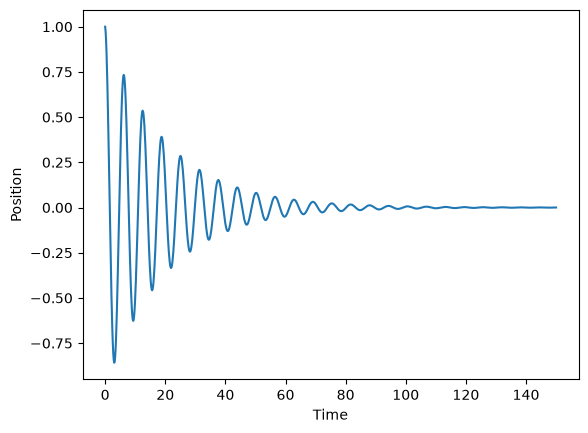

In [33]:
# oscillator = Harmonic_Oscillator(     # going to be more difficult traning model 
#     mass=1.0,
#     force_const=1,          # → ω₀ = √(k/m) = 1.0
#     initial_amplitude=1.0,    # Start with same amplitude as driven oscillation
#     velocity=0.0,             # Zero initial velocity for clean phase
#     damping_const=0.06,       # Very light damping (γ = b/2m = 0.005)
#     driving_force=0.5,
#     driving_frequency=0.7    # Close to ω₀ = 1.0 → beat frequency ≈ 0.05
# )


oscillator = Harmonic_Oscillator(       # simple training model
    mass=1.0,
    force_const=1,          # → ω₀ = √(k/m) = 1.0
    initial_amplitude=1.0,    # Start with same amplitude as driven oscillation
    velocity=0.0,             # Zero initial velocity for clean phase
    damping_const=0.1,       # Very light damping (γ = b/2m = 0.005)
    driving_force=0.0,
    driving_frequency=0.7    # Close to ω₀ = 1.0 → beat frequency ≈ 0.05
)



t = np.linspace(0, 150, 1000)
x = oscillator.get_x_pos(t)

plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("Position")


plt.show()